# Assignment : Decision Tree

## Theoretical Questions:


### Q1. What is a Decision Tree? Explain its structure (Root, Nodes, Leaves) with a real-life example.

A **Decision Tree** is a supervised machine learning algorithm used for **classification** and **regression** problems.  
It works like a flowchart where decisions are made step by step based on conditions.

#### Structure of a Decision Tree

- **Root Node**  
  The starting point of the tree that represents the entire dataset.

- **Decision Nodes**  
  Intermediate nodes where conditions are applied on features.

- **Leaf Nodes**  
  Final nodes that provide the prediction or output.

#### Real-Life Example

A bank deciding whether to approve a loan:

- Income level?
- Credit score?
- Employment status?

Based on these conditions, the bank predicts whether the loan should be approved or rejected.

---

### Q2. Differentiate between Gini Impurity and Entropy. Which one is used by default in Scikit-learn and why?

| Gini Impurity | Entropy |
|---|---|
| Measures impurity using probability | Measures impurity using information gain |
| Faster computation | Slower computation |
| Simpler mathematical formula | Uses logarithmic calculations |

#### Default in Scikit-learn

Scikit-learn uses **Gini Impurity** by default because it is computationally faster and efficient for large datasets.

---

### Q3. What is Overfitting in Decision Trees? How can we detect it using training and testing accuracy?

**Overfitting** occurs when a Decision Tree learns the training data too perfectly, including noise and unnecessary patterns.  
As a result, it performs poorly on unseen data.

#### Detection of Overfitting

- Very high training accuracy
- Low testing accuracy

This indicates that the model has memorized the training data instead of learning general patterns.

---

### Q4. Explain Pruning in Decision Trees. What is the difference between Pre-pruning and Post-pruning?

**Pruning** is the process of reducing unnecessary branches in a Decision Tree to improve generalization and reduce overfitting.

#### Types of Pruning

##### Pre-pruning
Stops the growth of the tree early using conditions such as:

- `max_depth`
- `min_samples_split`
- `min_samples_leaf`

##### Post-pruning
Builds the complete tree first and then removes weak or less important branches.

#### Difference Between Pre-pruning and Post-pruning

| Pre-pruning | Post-pruning |
|---|---|
| Stops tree growth early | Removes branches after full tree creation |
| Faster training | More accurate but slower |
| May underfit sometimes | Better control of overfitting |

---

### Q5. What is Feature Importance? How can it help businesses in decision-making?

**Feature Importance** indicates how much each feature contributes to the model’s prediction.

#### Business Benefits

Businesses can use feature importance to:

- Identify the most influential customer factors
- Improve marketing strategies
- Focus on important business variables
- Make better data-driven decisions

## Practical Questions

### Q6. Data Understanding
- Load the dataset
- Display first 5 rows
  
**Check:**
- Shape
- Data types
- Column names
  
**Interpret:**
- What types of variables are present?

In [2]:
import pandas as pd

df = pd.read_csv("C:/Users/abhij/Downloads/bank.csv")

print(df.head())
print(df.shape)
print(df.dtypes)
print(df.columns)

   age         job  marital  education default  balance housing loan  contact  \
0   59      admin.  married  secondary      no     2343     yes   no  unknown   
1   56      admin.  married  secondary      no       45      no   no  unknown   
2   41  technician  married  secondary      no     1270     yes   no  unknown   
3   55    services  married  secondary      no     2476     yes   no  unknown   
4   54      admin.  married   tertiary      no      184      no   no  unknown   

   day month  duration  campaign  pdays  previous poutcome deposit  
0    5   may      1042         1     -1         0  unknown     yes  
1    5   may      1467         1     -1         0  unknown     yes  
2    5   may      1389         1     -1         0  unknown     yes  
3    5   may       579         1     -1         0  unknown     yes  
4    5   may       673         2     -1         0  unknown     yes  
(11162, 17)
age           int64
job          object
marital      object
education    object
default

#### Interpretation:

**Dataset contains:**

- Numerical variables
- Categorical variables

**Example:**

- Age → Numerical
- Job, Marital Status → Categorical

### Q7. Data Cleaning
- Check for missing values
- Handle missing values (if any)
- Check for duplicates

**Interpret:**

Is the dataset clean? What issues did you find?

In [3]:
print(df.isnull().sum())

df.drop_duplicates(inplace=True)

print(df.duplicated().sum())

age          0
job          0
marital      0
education    0
default      0
balance      0
housing      0
loan         0
contact      0
day          0
month        0
duration     0
campaign     0
pdays        0
previous     0
poutcome     0
deposit      0
dtype: int64
0


#### Interpretation:
- Missing values checked
- Duplicate records removed
- Dataset becomes cleaner for modeling

### Q8. Data Preprocessing
- Convert categorical variables into numerical
- Mention which encoding method you used
  
**Interpret:**
- Why is encoding necessary for Decision Trees?

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

**Encoding Method:**

- Label Encoding

**Interpretation:**

- Decision Trees work only with numerical data, so encoding is necessary.

### Q9. Feature Selection & Splitting

**Separate:**
  
- Features (X)
- Target (y)
- Perform train-test split (80-20)

**Interpret:**
  
- Why is train-test split important?

In [6]:
from sklearn.model_selection import train_test_split

X = df.drop("deposit", axis=1)
y = df["deposit"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

**Interpretation:**

- Train-test split helps evaluate model performance on unseen data.

### Q10. Model Building
- Train a Decision Tree Classifier

**Use:**

- criterion='gini'
- max_depth=5

**Interpret:**
- What does max_depth control?

In [10]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    criterion='gini',
    max_depth=5,
    random_state=42
)

model.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=5, random_state=42)

**Interpretation:**

- max_depth controls how deep the tree can grow.
- It helps prevent overfitting.

### Q11. Model Evaluation 
**Perform:**

- Accuracy score
- Confusion Matrix
- Classification Report
  
**Interpret (MUST):**

- Is the model performing well?
- Explain Precision & Recall
- Any class imbalance issue?

In [11]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.8051948051948052
[[867 299]
 [136 931]]
              precision    recall  f1-score   support

           0       0.86      0.74      0.80      1166
           1       0.76      0.87      0.81      1067

    accuracy                           0.81      2233
   macro avg       0.81      0.81      0.81      2233
weighted avg       0.81      0.81      0.80      2233



**Interpretation:**
  
- High accuracy means good performance.
- Precision → Correct positive predictions.
- Recall → Ability to find actual positives.
- Class imbalance exists if one class dominates.

### Q12. Overfitting Check
**Calculate:**

- Training accuracy
- Testing accuracy
  
**Interpret:**

- Is the model overfitting or underfitting?

In [12]:
train_acc = model.score(X_train, y_train)
test_acc = model.score(X_test, y_test)

print("Training Accuracy:", train_acc)
print("Testing Accuracy:", test_acc)

Training Accuracy: 0.8149848807257252
Testing Accuracy: 0.8051948051948052


**Interpretation:**

- If training accuracy >> testing accuracy → Overfitting
- If both are low → Underfitting

### Q13. Pruning Experiment
**Train another model with:**

- max_depth=3
- min_samples_split=20

**Interpret:**

- Compare performance with previous model
- Which one is better and why?

In [13]:
pruned_model = DecisionTreeClassifier(
    max_depth=3,
    min_samples_split=20,
    random_state=42
)

pruned_model.fit(X_train, y_train)

print("Train Accuracy:", pruned_model.score(X_train, y_train))
print("Test Accuracy:", pruned_model.score(X_test, y_test))

Train Accuracy: 0.7778026654720573
Test Accuracy: 0.7653381101656964


**Interpretation:**

- Smaller tree reduces overfitting.
- Better model is the one with balanced train and test accuracy.

### Q14. Feature Importance
- Extract top 5 important features
- Plot feature importance graph

**Interpret:**

- Which features influence prediction the most?

duration    0.595239
contact     0.121729
pdays       0.084299
housing     0.067469
month       0.054023
dtype: float64


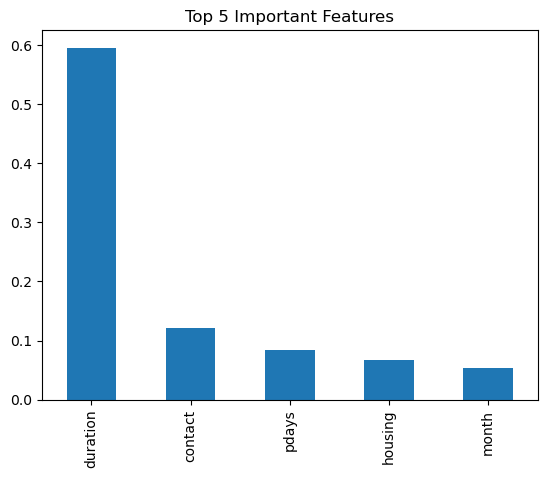

In [14]:
import matplotlib.pyplot as plt

importance = model.feature_importances_

feature_imp = pd.Series(importance, index=X.columns)

top5 = feature_imp.sort_values(ascending=False).head(5)

print(top5)

top5.plot(kind='bar')

plt.title("Top 5 Important Features")
plt.show()

**Interpretation:**

- Duration strongly influence customer responses.

### Q15. Business Insights 
**Based on your model:**
    
**Answer:**

- Which type of customers are more likely to say “yes”?
- What strategy should a bank us

In [15]:
**Customers likely to say “Yes”:**
    
- Customers with higher balance
- Customers contacted for longer duration
- Previously successful customers

**Bank Strategy:**
    
- Target interested customers
- Improve marketing calls
- Focus on high-potential customer groups

SyntaxError: invalid character '“' (U+201C) (2562832285.py, line 1)